In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import signal
from tqdm.autonotebook import tqdm

C:\Users\shiva\AppData\Local\Temp\ipykernel_15620\3490735909.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## HH Model

In [2]:
class HHModel():
    def __init__(self, dt = 0.01, iter = 10000):
        self.gK_max = 0.36 # max conductance of K channel
        self.gNa_max = 1.20 # max condutance of Na channel
        self.gl = 0.003 # Leaky channel conductance
        self.E_Na = 50 # Nernst potential of Na channel
        self.E_K = -77 # Nernst potential of K channel
        self.E_l = -54.387 # Nernst potential of leaky channel
        self.C = 0.01 # Membrane conductance
        self.v_monitor = [] # Monitor to append all the voltage values
        self.gNa_monitor = [] # Monitor to append all the Na conductance values
        self.gK_monitor = [] # Monitor to append all the K conductance values
        self.m_monitor = [] # Monitor to append all the values of gating variable m
        self.n_monitor = [] # Monitor to append all the values of gating variable n
        self.h_monitor = [] # Monitor to append all the values of gating variable h
        self.dt = dt
        self.iter = iter

    def model(self, I_app: float):
        '''
        Computes the voltage using Hodgkin Huxeley model
        -------------------------------------------------
        Args:
            I_app: External current (micro amperes)
            dt: Step length for Euler method. Default = 0.01 ms
            iter: Number of iterations. Default = 10000
        Returns:
            v_monitor: voltage
            m: Gating variable
            n: Gating variable
            h: Gating variable
            gNa: Conductance of Na channel
            gK: Conductance of K channel
        --------------------------------------------------
        '''
        v = -64.9964
        m = 0.0530
        h = 0.5960
        n = 0.3177
        dt = self.dt
        iter = self.iter

        for i in range(iter):
            gNa = self.gNa_max * (m**3) * h
            gK = self.gK_max * n**4


            dv = (-gNa * (v - self.E_Na) - gK * (v - self.E_K) - self.gl *(v- self.E_l) + I_app)/self.C
            v = v + dt* dv

            alpha_m = 0.1 * (v + 40) / (1- np.exp(-(v + 40)/10))
            beta_m = 4 * np.exp(-0.0556 * (v + 65))
            alpha_h = 0.07 * (np.exp(-0.05 *(v + 65)))
            beta_h = 1/(1 + np.exp(-0.1 * (v + 35)))
            alpha_n = 0.01 * (v + 55)/(1 - np.exp(-(v + 55)/10))
            beta_n = 0.125 * np.exp(-(v + 65)/80)

            dm = alpha_m * (1 - m) - beta_m * m
            dn = alpha_n * (1 - n) - beta_n * n
            dh = alpha_h * (1 - h) - beta_h * h

            m = m + dt * dm
            n = n + dt * dn
            h = h + dt * dh

            self.v_monitor.append(v)
            self.m_monitor.append(m)
            self.n_monitor.append(n)
            self.h_monitor.append(h)
            self.gNa_monitor.append(gNa)
            self.gK_monitor.append(gK)

        return self.v_monitor, self.m_monitor, self.n_monitor, self.h_monitor, self.gNa_monitor, self.gK_monitor


## Simulate HH Model

In [3]:
HH = HHModel(dt = 0.01, iter = 100000) # dt is in ms
v, m, n, h, gNa, gK = HH.model(I_app = 2)

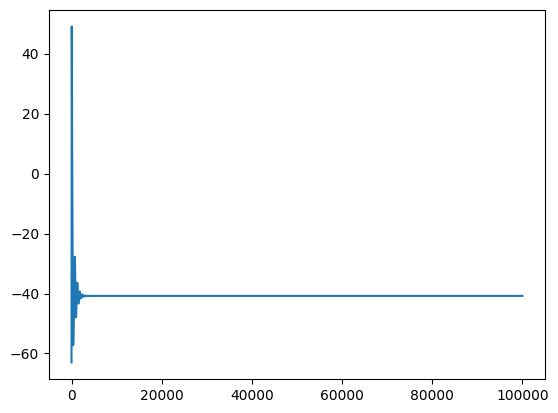

In [5]:
plt.plot(HH.v_monitor)